# Load the simulated data used in the Bayesian SBD at Scale paper

In [ ]:
# Repo/data paths that work on any machine
from __future__ import annotations

import os
import sys
from pathlib import Path
import pickle
import numpy as np
from matplotlib import pyplot as plt

Set repo and data filepaths:

In [ ]:
# Detect the repo root by walking upward until `pyproject.toml` (or `.git`) is found.
def find_repo_root(start: Path | None = None) -> Path:
    """Find the repo root by walking upwards until pyproject.toml (or .git) is found."""
    here = (start or Path.cwd()).resolve()
    for p in (here, *here.parents):
        if (p / "pyproject.toml").exists() or (p / ".git").exists():
            return p
    return here


REPO_ROOT = find_repo_root()


# To import `from src...`
repo_root_str = str(REPO_ROOT)
if repo_root_str in sys.path:
    sys.path.remove(repo_root_str)
sys.path.insert(0, repo_root_str)

# Data root: overrideable per-user/machine. Default: <repo>/data
DATA_ROOT = Path(os.environ.get("BSBD_DATA_DIR", str(REPO_ROOT / "data"))).expanduser().resolve()


Import the simulated dataset, *relative* to DATA_ROOT. The dataset is a ConvolutionalModel object, and the values for the simulated data and the true parameters are stored in the `theta` dictionary.

The keys in `theta` should be:
* d_star: the simulated data.
* c_star: the true image.
* w_star: the true blur kernel.
* sigma2c: the image variance.
* sigma2w: the blur variance.
* zeta: the signal-to-noise ratio.

In [ ]:
rel_dataset = Path(
    "bayesian_sbd_at_scale/numerical_experiments/"
    "C_nv24_nh6_mv0_mh0_k12_snr138.0_eb014c16-06e4-4a9b-86ad-d0cb26046a7d.pkl"
)
path_data = DATA_ROOT / rel_dataset

print("REPO_ROOT:", REPO_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("Dataset:", path_data)
print("Exists:", path_data.exists())

# Load the dataset
with path_data.open("rb") as f:
    data_true = pickle.load(f)

print("Loaded:", type(data_true))
print("Has lattice:", hasattr(data_true, "lattice"))

# Verify that the `theta` dictionary with the parameter values exists
if hasattr(data_true, "theta"):
    print("theta keys:", list(getattr(data_true, "theta").keys())[:10])

REPO_ROOT: /Users/guillers/Documents/GitHub/bsbd
DATA_ROOT: /Users/guillers/Documents/GitHub/bsbd/data
Dataset: /Users/guillers/Documents/GitHub/bsbd/data/bayesian_sbd_at_scale/numerical_experiments/C_nv24_nh6_mv0_mh0_k12_snr138.0_eb014c16-06e4-4a9b-86ad-d0cb26046a7d.pkl
Exists: True
Loaded: <class 'src.classes.model.ConvolutionalModel'>
Has lattice: True
theta keys: ['sigma2c', 'sigma2w', 'zeta', 'w_star', 'c_star', 'd_star']


Univariate parameters (marginal variances):
- sigma2c: 0.0019194322798388073
- sigma2w: 5.074965030902906
- zeta: 0.007260547908697199


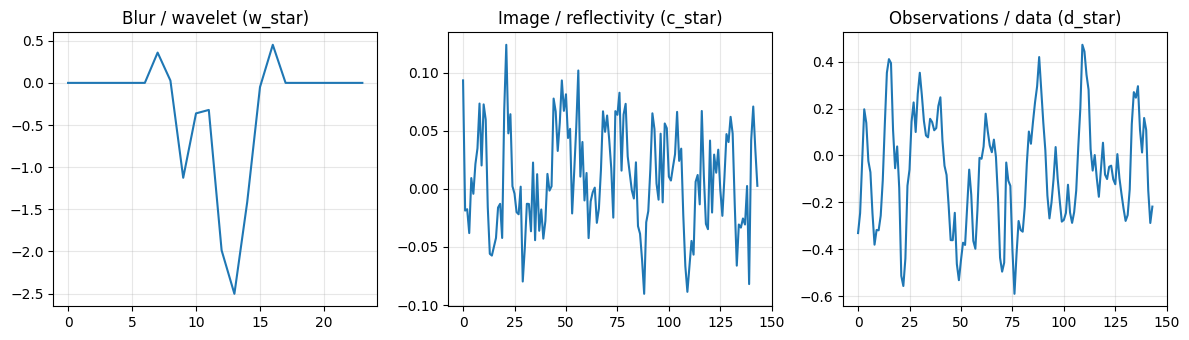

In [ ]:
# Plot the blur, the image, the observations, and print values for the univariate parameters
theta = getattr(data_true, "theta", None)
if theta is None:
    raise AttributeError("Expected `data_true.theta` to exist.")

w_star = theta.get("w_star")  # blur
c_star = theta.get("c_star")  # image
d_star = theta.get("d_star")  # data / observations

def _as_array(x):
    if x is None:
        return None
    return np.asarray(x)

def _plot_any(ax, x, title: str):
    ax.set_title(title)
    if x is None:
        ax.text(0.5, 0.5, "Missing", ha="center", va="center")
        ax.axis("off")
        return
    arr = np.asarray(x)
    arr = np.squeeze(arr)
    if arr.ndim == 0:
        ax.text(0.5, 0.5, str(arr), ha="center", va="center")
        ax.axis("off")
        return
    if arr.ndim == 1:
        ax.plot(arr)
        ax.grid(True, alpha=0.3)
        return
    if arr.ndim == 2:
        im = ax.imshow(arr, aspect="auto")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        return
    # Higher-dim: show a flattened view to stay safe
    flat = arr.reshape(-1)
    ax.plot(flat)
    ax.grid(True, alpha=0.3)
    ax.set_ylabel("(flattened)")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
_plot_any(axes[0], _as_array(w_star), "Blur (w_star)")
_plot_any(axes[1], _as_array(c_star), "Image (c_star)")
_plot_any(axes[2], _as_array(d_star), "Observations / data (d_star)")
plt.tight_layout()

# Print univariate parameters 
sigma_keys = sorted([k for k in theta.keys() if str(k).startswith("sigma") or str(k) == 'zeta'])
if not sigma_keys:
    print("No sigma* keys found in theta. Available keys:", sorted(theta.keys()))
else:
    print("Univariate parameters (marginal variances):")
    for k in sigma_keys:
        v = theta.get(k)
        v_arr = np.asarray(v) if v is not None else None
        # pretty print scalars / length-1 arrays
        if v_arr is None:
            v_print = None
        elif v_arr.ndim == 0:
            v_print = float(v_arr)
        elif v_arr.size == 1:
            v_print = float(v_arr.reshape(-1)[0])
        else:
            v_print = f"array shape={v_arr.shape}"
        print(f"- {k}: {v_print}")